In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [14]:
import pandas as pd
import numpy as np

np.random.seed(42)

rows = 500

regions = ['North','South','East','West']
countries = ['India','USA','UK','Canada']
segments = ['Consumer','Corporate','Home Office']
categories = ['Electronics','Furniture','Office Supplies']
products = ['Laptop','Chair','Printer','Desk','Monitor']
sales_rep = ['John','Emma','David','Sophia','Michael']

dates = pd.date_range(start='2023-01-01', end='2024-12-31')

data = {
    'Order ID': [f'ORD{i}' for i in range(1, rows+1)],
    'Order Date': np.random.choice(dates, rows),
    'Region': np.random.choice(regions, rows),
    'Country': np.random.choice(countries, rows),
    'Customer Segment': np.random.choice(segments, rows),
    'Product Category': np.random.choice(categories, rows),
    'Product Name': np.random.choice(products, rows),
    'Sales Representative': np.random.choice(sales_rep, rows),
    'Units Sold': np.random.randint(1,50,rows),
    'Unit Price': np.random.randint(500,5000,rows),
    'Marketing Spend': np.random.randint(1000,10000,rows)
}

df = pd.DataFrame(data)

df['Revenue'] = df['Units Sold'] * df['Unit Price']
df['Cost'] = df['Revenue'] * np.random.uniform(0.55,0.85,len(df))
df['Profit'] = df['Revenue'] - df['Cost']

df['Forecasted Revenue'] = df['Revenue'] * np.random.uniform(0.9,1.1,len(df))
df['Actual Revenue'] = df['Revenue']

df['Revenue Variance %'] = ((df['Actual Revenue'] - df['Forecasted Revenue'])
                             /df['Forecasted Revenue'])*100

df['Sales Target'] = df['Revenue'] * np.random.uniform(0.95,1.15,len(df))

df['Target Achievement %'] = (df['Actual Revenue']
                              /df['Sales Target'])*100

df['Month'] = pd.to_datetime(df['Order Date']).dt.month_name()
df['Quarter'] = pd.to_datetime(df['Order Date']).dt.quarter
df['Year'] = pd.to_datetime(df['Order Date']).dt.year

season_map = {
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',
    9:'Autumn',10:'Autumn',11:'Autumn'
}

df['Season'] = pd.to_datetime(df['Order Date']).dt.month.map(season_map)

df.head()

,Order ID,Order Date,Region,Country,Customer Segment,Product Category,Product Name,Sales Representative,Units Sold,Unit Price,...,Profit,Forecasted Revenue,Actual Revenue,Revenue Variance %,Sales Target,Target Achievement %,Month,Quarter,Year,Season
0,ORD1,2023-04-13,North,UK,Corporate,Furniture,Monitor,Michael,11,4023,...,19641.417716,44293.881139,44253,-0.092295,47298.044200,93.562008,April,2,2023,Spring
1,ORD2,2024-03-11,North,India,Corporate,Electronics,Desk,Sophia,46,2129,...,19784.087685,90437.742799,97934,8.288859,104586.725079,93.639035,March,1,2024,Spring
2,ORD3,2023-09-28,North,USA,Corporate,Electronics,Laptop,Sophia,19,1816,...,11742.445780,32220.261521,34504,7.087896,33243.754315,103.790925,September,3,2023,Autumn
3,ORD4,2023-04-17,East,UK,Consumer,Furniture,Desk,Emma,11,3357,...,12698.862736,35832.520694,36927,3.054430,41221.911323,89.580999,April,2,2023,Spring
4,ORD5,2023-03-13,East,Canada,Corporate,Furniture,Printer,David,13,1624,...,7584.618821,22216.900220,21112,-4.973242,20805.143638,101.474906,March,1,2023,Spring


In [15]:
df.to_csv("Sales_Forecasting_Dataset.csv", index=False)

from google.colab import files
files.download("Sales_Forecasting_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
total_revenue = df['Revenue'].sum()

print("Total Revenue : ₹{:,.0f}".format(total_revenue))

Total Revenue : ₹36,194,095


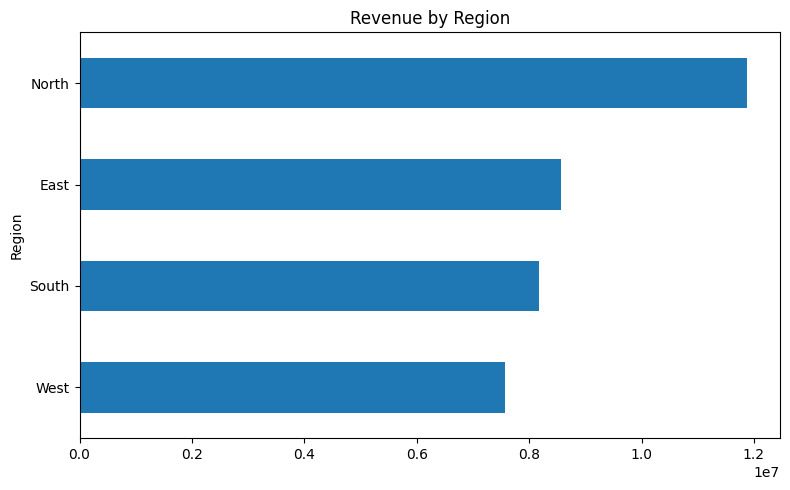

In [17]:
region_rev = df.groupby('Region')['Revenue'].sum().sort_values()

plt.figure(figsize=(8,5))
region_rev.plot(kind='barh')

plt.title('Revenue by Region')
plt.tight_layout()

plt.savefig("Revenue_by_Region.png")
plt.show()

In [18]:
files.download("Revenue_by_Region.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

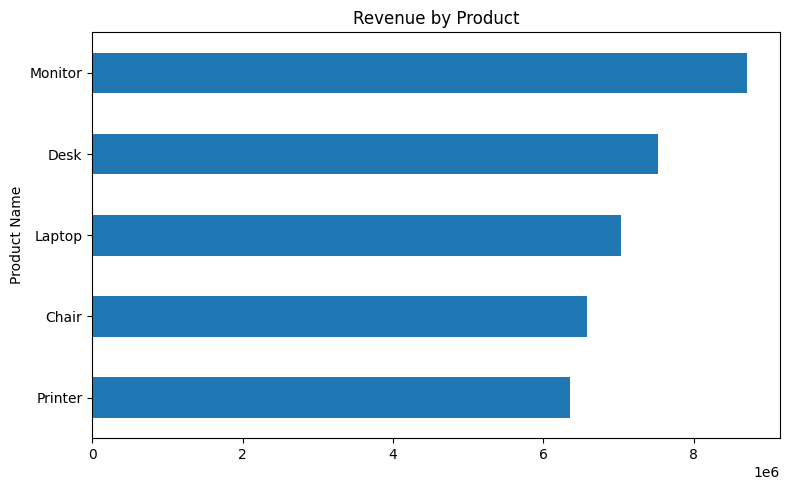

In [19]:
product_rev = df.groupby('Product Name')['Revenue'].sum()

plt.figure(figsize=(8,5))
product_rev.sort_values().plot(kind='barh')

plt.title('Revenue by Product')
plt.tight_layout()

plt.savefig("Revenue_by_Product.png")
plt.show()

In [20]:
files.download("Revenue_by_Product.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

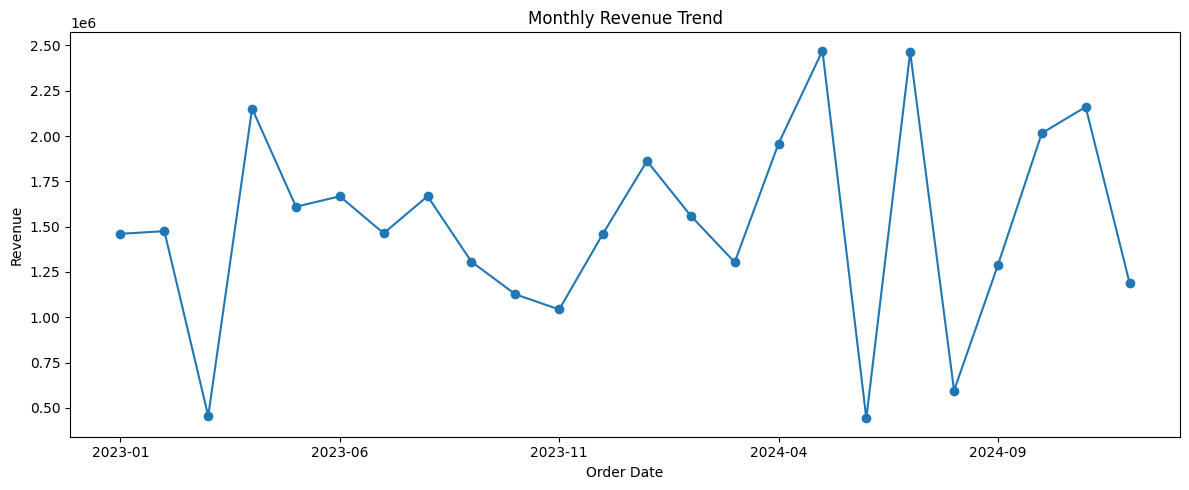

In [21]:
monthly = df.groupby(
    pd.to_datetime(df['Order Date']).dt.to_period('M')
)['Revenue'].sum()

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(12,5))
monthly.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')

plt.tight_layout()

plt.savefig("Monthly_Revenue_Trend.png")
plt.show()

In [22]:
files.download("Monthly_Revenue_Trend.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
profit_margin = (
    df['Profit'].sum()
    / df['Revenue'].sum()
)*100

print("Profit Margin : {:.2f}%".format(profit_margin))

Profit Margin : 30.04%


In [24]:
monthly_df = monthly.reset_index()

monthly_df.columns = ['Month','Revenue']

monthly_df['Month_Number'] = range(len(monthly_df))

X = monthly_df[['Month_Number']]
y = monthly_df['Revenue']

model = LinearRegression()

model.fit(X,y)

LinearRegression()

In [25]:
future = pd.DataFrame({
    'Month_Number': range(
        len(monthly_df),
        len(monthly_df)+6
    )
})

future['Forecast Revenue'] = model.predict(future)

future

,Month_Number,Forecast Revenue
0,24,1.625878e+06
1,25,1.635301e+06
2,26,1.644724e+06
3,27,1.654148e+06
4,28,1.663571e+06
5,29,1.672994e+06


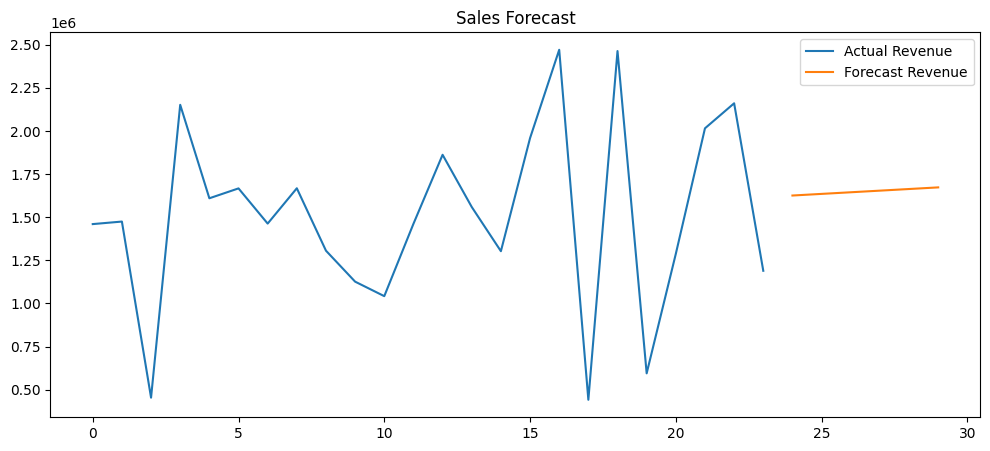

In [26]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_df['Month_Number'],
    monthly_df['Revenue'],
    label='Actual Revenue'
)

plt.plot(
    future['Month_Number'],
    future['Forecast Revenue'],
    label='Forecast Revenue'
)

plt.legend()

plt.title("Sales Forecast")

plt.savefig("Sales_Forecast.png")

plt.show()

In [27]:
files.download("Sales_Forecast.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
pred = model.predict(X)

mae = mean_absolute_error(y,pred)

r2 = r2_score(y,pred)

print("MAE:",mae)
print("R² Score:",r2)

MAE: 420110.70530193235
R² Score: 0.014564467194468245


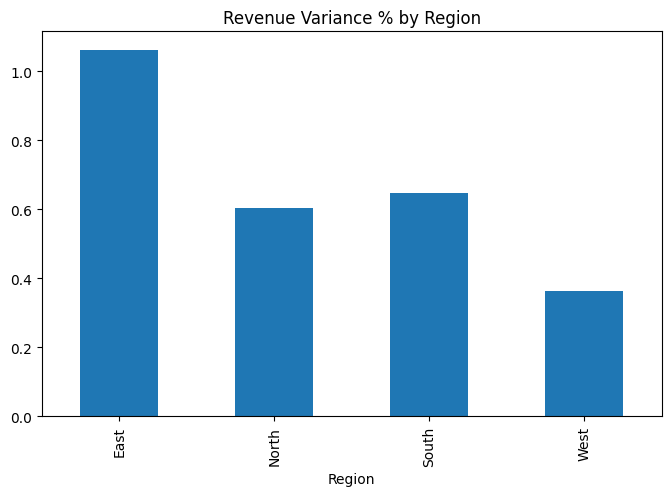

In [29]:
variance = df.groupby('Region')['Revenue Variance %'].mean()

plt.figure(figsize=(8,5))
variance.plot(kind='bar')

plt.title('Revenue Variance % by Region')

plt.savefig("Revenue_Variance.png")

plt.show()

In [30]:
files.download("Revenue_Variance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

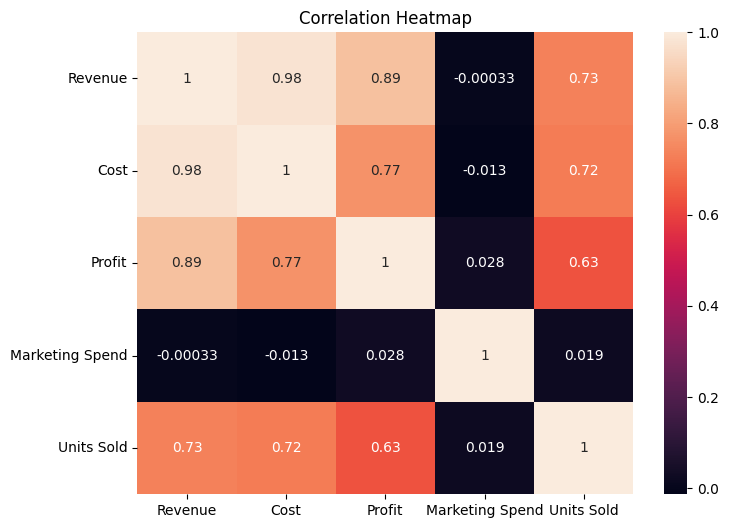

In [31]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Revenue',
        'Cost',
        'Profit',
        'Marketing Spend',
        'Units Sold']].corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.savefig("Correlation_Heatmap.png")

plt.show()

In [32]:
files.download("Correlation_Heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>